# Predict the pedestal using ESCAPE for ARC baseline scenario

In [1]:
import os
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sys
from pathlib import Path
import urllib.request # needed for geqdsk import
ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(ROOT))
from src.profiles_loop_solve import profiles_loop_solve

from examples.device_prediction.helper_functions import calc_pressure_profile

Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified


In [2]:
# Import the ARC baseline scenario geqdsk if it does not currently exist
_ZENODO = 'https://zenodo.org/records/19498373/files'

def _fetch(filename):
    if not os.path.exists(filename):
        print(f'Downloading {filename} from Zenodo...', end=' ', flush=True)
        urllib.request.urlretrieve(f'{_ZENODO}/{filename}?download=1', filename)
        print('done.')

mhd_fp = 'geqdsk-ARCv3a'
_fetch(mhd_fp) # places geqdsk file in the current directory

Loaded ne: 32 points (ne [10^20 particles/m^3])
Loaded Te: 43 points (Te [keV])


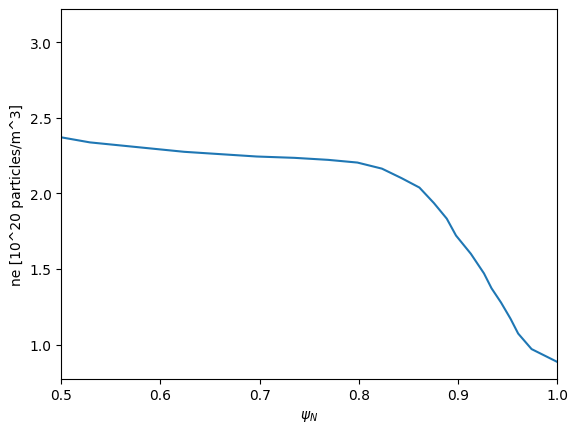

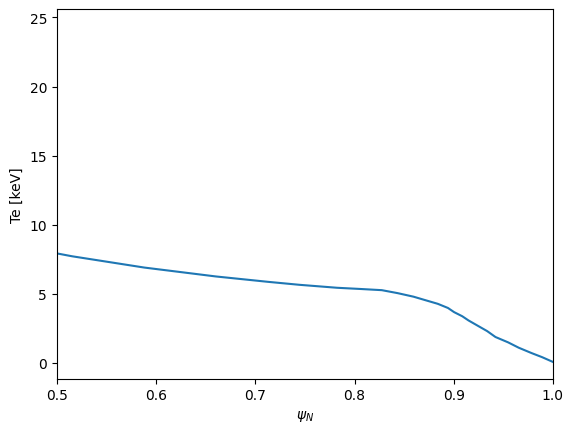

In [8]:
# Import reference profiles digitized from Howard et al. 2026 Fig. 4

def load_digitized_profile(filepath):
    """Load rho and profile data from a Web Plot Digitizer export.

    Parameters
    ----------
    filepath : str or Path
        Path to an ARC_*_extracted.txt file.

    Returns
    -------
    rho : ndarray
        Normalized radial coordinate.
    profile : ndarray
        ne in 10^20 m^-3 or Te in keV, depending on the file.
    quantity : str
        'ne' or 'Te'.
    units : str
        Unit string parsed from the file header.
    """
    filepath = Path(filepath)
    data_lines = []
    quantity = None
    units = None

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.lower().startswith('rho,'):
                header = line
                if 'ne' in header.lower():
                    quantity = 'ne'
                elif 'te' in header.lower():
                    quantity = 'Te'
                units = header.split(',', 1)[1].strip()
                continue
            if quantity is not None:
                parts = [part.strip() for part in line.split(',')]
                if len(parts) == 2:
                    try:
                        data_lines.append((float(parts[0]), float(parts[1])))
                    except ValueError:
                        pass

    if not data_lines:
        raise ValueError(f'No profile data found in {filepath}')

    data = np.array(data_lines)
    sort_idx = np.argsort(data[:, 0])
    data = data[sort_idx]
    return data[:, 0], data[:, 1], quantity, units


ne_fp = 'ARC_ne_extracted.txt'
Te_fp = 'ARC_Te_extracted.txt'

rho_ne, ne_ref, _, ne_units = load_digitized_profile(ne_fp)
rho_Te, Te_ref, _, Te_units = load_digitized_profile(Te_fp)

np.save('ARC_ne_extracted.npy', {'rho': rho_ne, 'ne': ne_ref, 'units': ne_units})
np.save('ARC_Te_extracted.npy', {'rho': rho_Te, 'Te': Te_ref, 'units': Te_units})

print(f'Loaded ne: {len(rho_ne)} points ({ne_units})')
print(f'Loaded Te: {len(rho_Te)} points ({Te_units})')

fig,ax = plt.subplots()
ax.plot(rho_ne**2, ne_ref, label='ne')
ax.set_xlabel(r'$\psi_N$')
ax.set_ylabel('ne [10^20 particles/m^3]')

fig1,ax1 = plt.subplots()
ax1.plot(rho_Te**2, Te_ref, label='Te')
ax1.set_xlabel(r'$\psi_N$')
ax1.set_ylabel('Te [keV]')

ax.set_xlim(0.5, 1)
ax1.set_xlim(0.5, 1)

manual_profs = {
    'ne': ne_ref,
    'Te': Te_ref,
    'rho_ne': rho_ne,
    'rho_Te': rho_Te
}


In [4]:
# Parameters for ESCAPE #

# Output directory
out_dir = 'ARC_output_logs'
Path(out_dir).mkdir(parents=True, exist_ok=True)

verbose = True
verbose_sc = True

# Scan parameters
x_res = 50
free_params = {
    'alpha_crit': 10,
    'C_KBM': 0.1,
    'De_chie_etg': 1,
    'nFC_x0': 1e15,
    'ncx_x0_ratio': 17.8
}
epednn_model = 'EPED1' # 'EPED1' or 'EPED_SPARC'
eped_tol_max = 1e-5
eped_iter_max = 5
EPEDNN_core = 'previous T, stiched ne'
kbm_treatment = "picard"
kbm_gate_eps = 0.1
picard_gate_mode = "average"
picard_max_it = 50
picard_rtol = 1e-8
picard_relax = 1.0

verbose_EPEDNNloop = True
verbose_sc = False

Setting up EPEDNN...
Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Base model built.
------------------------------------------------
ESCAPE Loop Iter 0
betan: [1.75205989]
Pedestal height: 0.10307788423038201 MPa, Pedestal width: 0.03624744036529397 (psi_N)
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 1
betan: [1.2181374]
Pedestal height: 0.11281648705422925 MPa, Pedestal width: 0.03985917225667628 (psi_N)
Normalized pedestal pressure height and width tolerance: 0.19411912057065456


┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 2
betan: [1.29369034]
Pedestal height: 0.11137304821088762 MPa, Pedestal width: 0.0393248177851489 (psi_N)
Normalized pedestal pressure height and width tolerance: -0.0262006339874575
Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 3
betan: [1.2821029]
Pedestal height: 0.11097303458122393 MPa, Pedestal width: 0.0392051704733995 (psi_N)
Normalized pedestal pressure height and width tolerance: -0.006634195084194329


┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86
┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


Setting up EPEDNN...
------------------------------------------------
ESCAPE Loop Iter 4
betan: [1.27998015]
Pedestal height: 0.11026575252688423 MPa, Pedestal width: 0.03897798990621499 (psi_N)
Normalized pedestal pressure height and width tolerance: -0.012168117032423022
Setting up EPEDNN...


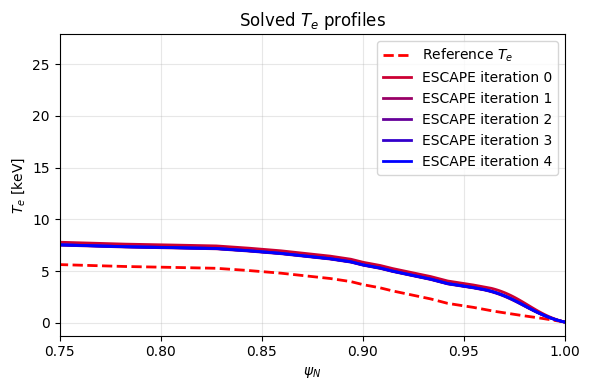

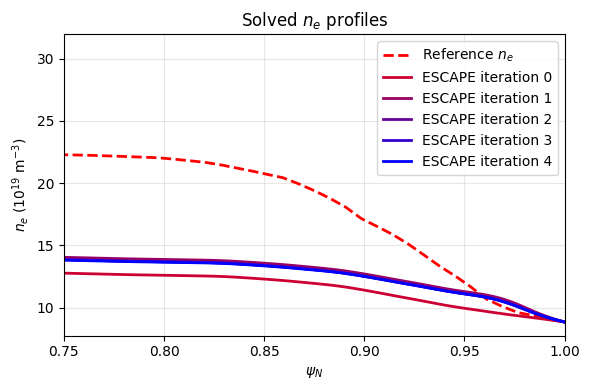

┌ Warning: Extrapolation warning on bt=11.343645965522871 is above bound of 7.999000072479248
└ @ EPEDNN ~/software/saarelma-conner-ped/dependencies/EPEDNN.jl/src/EPEDNN.jl:86


In [5]:
# Model run
ped_wid, ped_h_out = profiles_loop_solve(
    MHD_FP = mhd_fp,
    kprof_loc = 'manual rho grid',
    manual_profs = manual_profs,
    P_tot_e = ( 21.5 + 0.8 + 227 ) * 0.5 * 1e6, # table 4 of Hillesheim et al. 2026
    psi_N_inner = 0.75,
    out_dir = out_dir,
    species = 'D-T',
    # Z_i = Zeff,
    x_res = x_res,
    free_params = free_params,
    eped_tol_max = eped_tol_max,
    eped_iter_max = eped_iter_max,
    kbm_gate_eps = kbm_gate_eps,
    kbm_treatment = kbm_treatment,
    picard_gate_mode = picard_gate_mode,
    picard_max_it = picard_max_it,
    picard_rtol = picard_rtol,
    picard_relax = picard_relax,
    ig = 'manual',
    epednn_model = epednn_model,
    verbose = verbose_EPEDNNloop,
    verbose_sc = verbose_sc,
)

In [6]:
# Profile pressure at the EPEDNN-predicted pedestal top (psi_N = 1 - ped_wid)
psi_N_p, p_Pa, p_mode = calc_pressure_profile(manual_profs)
psi_ped_top = 1.0 - float(ped_wid)
p_at_ped_top = float(np.interp(psi_ped_top, psi_N_p, p_Pa))

print(f'Pressure formula: {p_mode}')
print(f'EPEDNN ped_top at psi_N = 1 - ped_wid = {psi_ped_top:.6f}')
print(f'Profile p(psi_ped_top) = {p_at_ped_top/1e3:.3f} kPa  ({p_at_ped_top/1e6:.4f} MPa)')
print(f'EPEDNN ped_h_out       = {float(ped_h_out)*1e3:.3f} kPa  ({float(ped_h_out):.4f} MPa)')
print(f'Accuracy of EPEDNN pedestal heightprediction: {100*(float(p_at_ped_top/1e6) - float(ped_h_out))/float(ped_h_out):.2f}%')


Pressure formula: 2*ne*Te
EPEDNN ped_top at psi_N = 1 - ped_wid = 0.961022
Profile p(psi_ped_top) = 43.862 kPa  (0.0439 MPa)
EPEDNN ped_h_out       = 110.266 kPa  (0.1103 MPa)
Accuracy of EPEDNN pedestal heightprediction: -60.22%


In [ ]:
# Save model output
out_dict = {
    'mhd_fp': mhd_fp,
    'profiles': manual_profs,
    'ESCAPE_ped_h': ped_h_out,
    'ESCAPE_ped_wid': ped_wid,
    'experimental_ped_h': p_at_ped_top,
}
np.save(out_dir+'/ARC_pedestal_prediction.npy', out_dict)